# Exoplanet mass-semimajor axis plot

Use a live query to the NASA Exoplanet Archive at IPAC using `astroquery` to create a plot of best estimate
planet mass vs. orbital semimajor axis.

In [3]:
%matplotlib inline

import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# astroquery for the NASA Exoplanet Archive

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)
warnings.filterwarnings('ignore',category=RuntimeWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

In [4]:
# graphic aspect ratio = width/height

aspect = 4.0/3.0 # 4:3 letter
#aspect = 16.0/9.0 # wide-screen

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Retrieve the exoplanet archive data

Use `astroquery` to read the NASA Exoplanet Archive selecting out all data where `discoverymethod` is 
`Radial Velocity` and only return the date of discovery (`disc_year`) and the RV semiamplitude (`pl_rvamp`) in 
units of meters/second.

In [17]:
exoData = NasaExoplanetArchive.query_criteria(table="pscomppars",
                                              select="pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2")

exSMA = np.array(exoData['pl_orbsmax'])
exMass = np.array(exoData['pl_bmasse'])

plotFile = f"exoplanet_aMe_2025.png"

print(f"Retrieved {len(exSMA)} exoplanets from the NASA Exoplanet Archive")

# axis limits

aMin = 0.007 # au
aMax = 4000. # au

mMin = 0.08 # M_earth
mMax = 2e4 # M_earth

Retrieved 5876 exoplanets from the NASA Exoplanet Archive


## Solar system data

### Planets, Dwarf Planets, and Giant Moons

Planets, dwarf planets, and giant moons are from the JPL Solar System Dynamics database, extracted and organized
into a single CSV file `MassOrbit_Major.csv`.  For this plot we use 4 columns:
 * `Body` - name of the body
 * `a` - orbit semimajor axis in au
 * `ME` - mass in units of M$_E$=5.97271$\times$10$^{24}$ kg
 * `RE` - radius in units of R$_E$=6371 km
 * `Type` - body type code: T = terrestrial planet, G = gas giant, I = ice giant, D = dwarf planet, DC = dwarf planet candidate, GM = giant moon.

In [13]:
majorFile = 'MassOrbit_Major.xlsx'

data = pd.read_excel(majorFile,comment='#')
bodyName = np.array(data['Body'])
bodyAU = np.array(data['a'])
bodyType = np.array(data['Type'])
bodyMass = np.array(data['ME'])
bodyRadius = np.array(data['RE'])
bodyAU = np.array(data['a'])

# colors etc.

bodySize = {'T':5,'G':8,'I':6,'D':4,'DC':3,'GM':3}
bodyColor = {'T':'#bbbbbb','G':'beige','I':'cyan','D':'snow','DC':'white','GM':'orange'}

## Make the plot

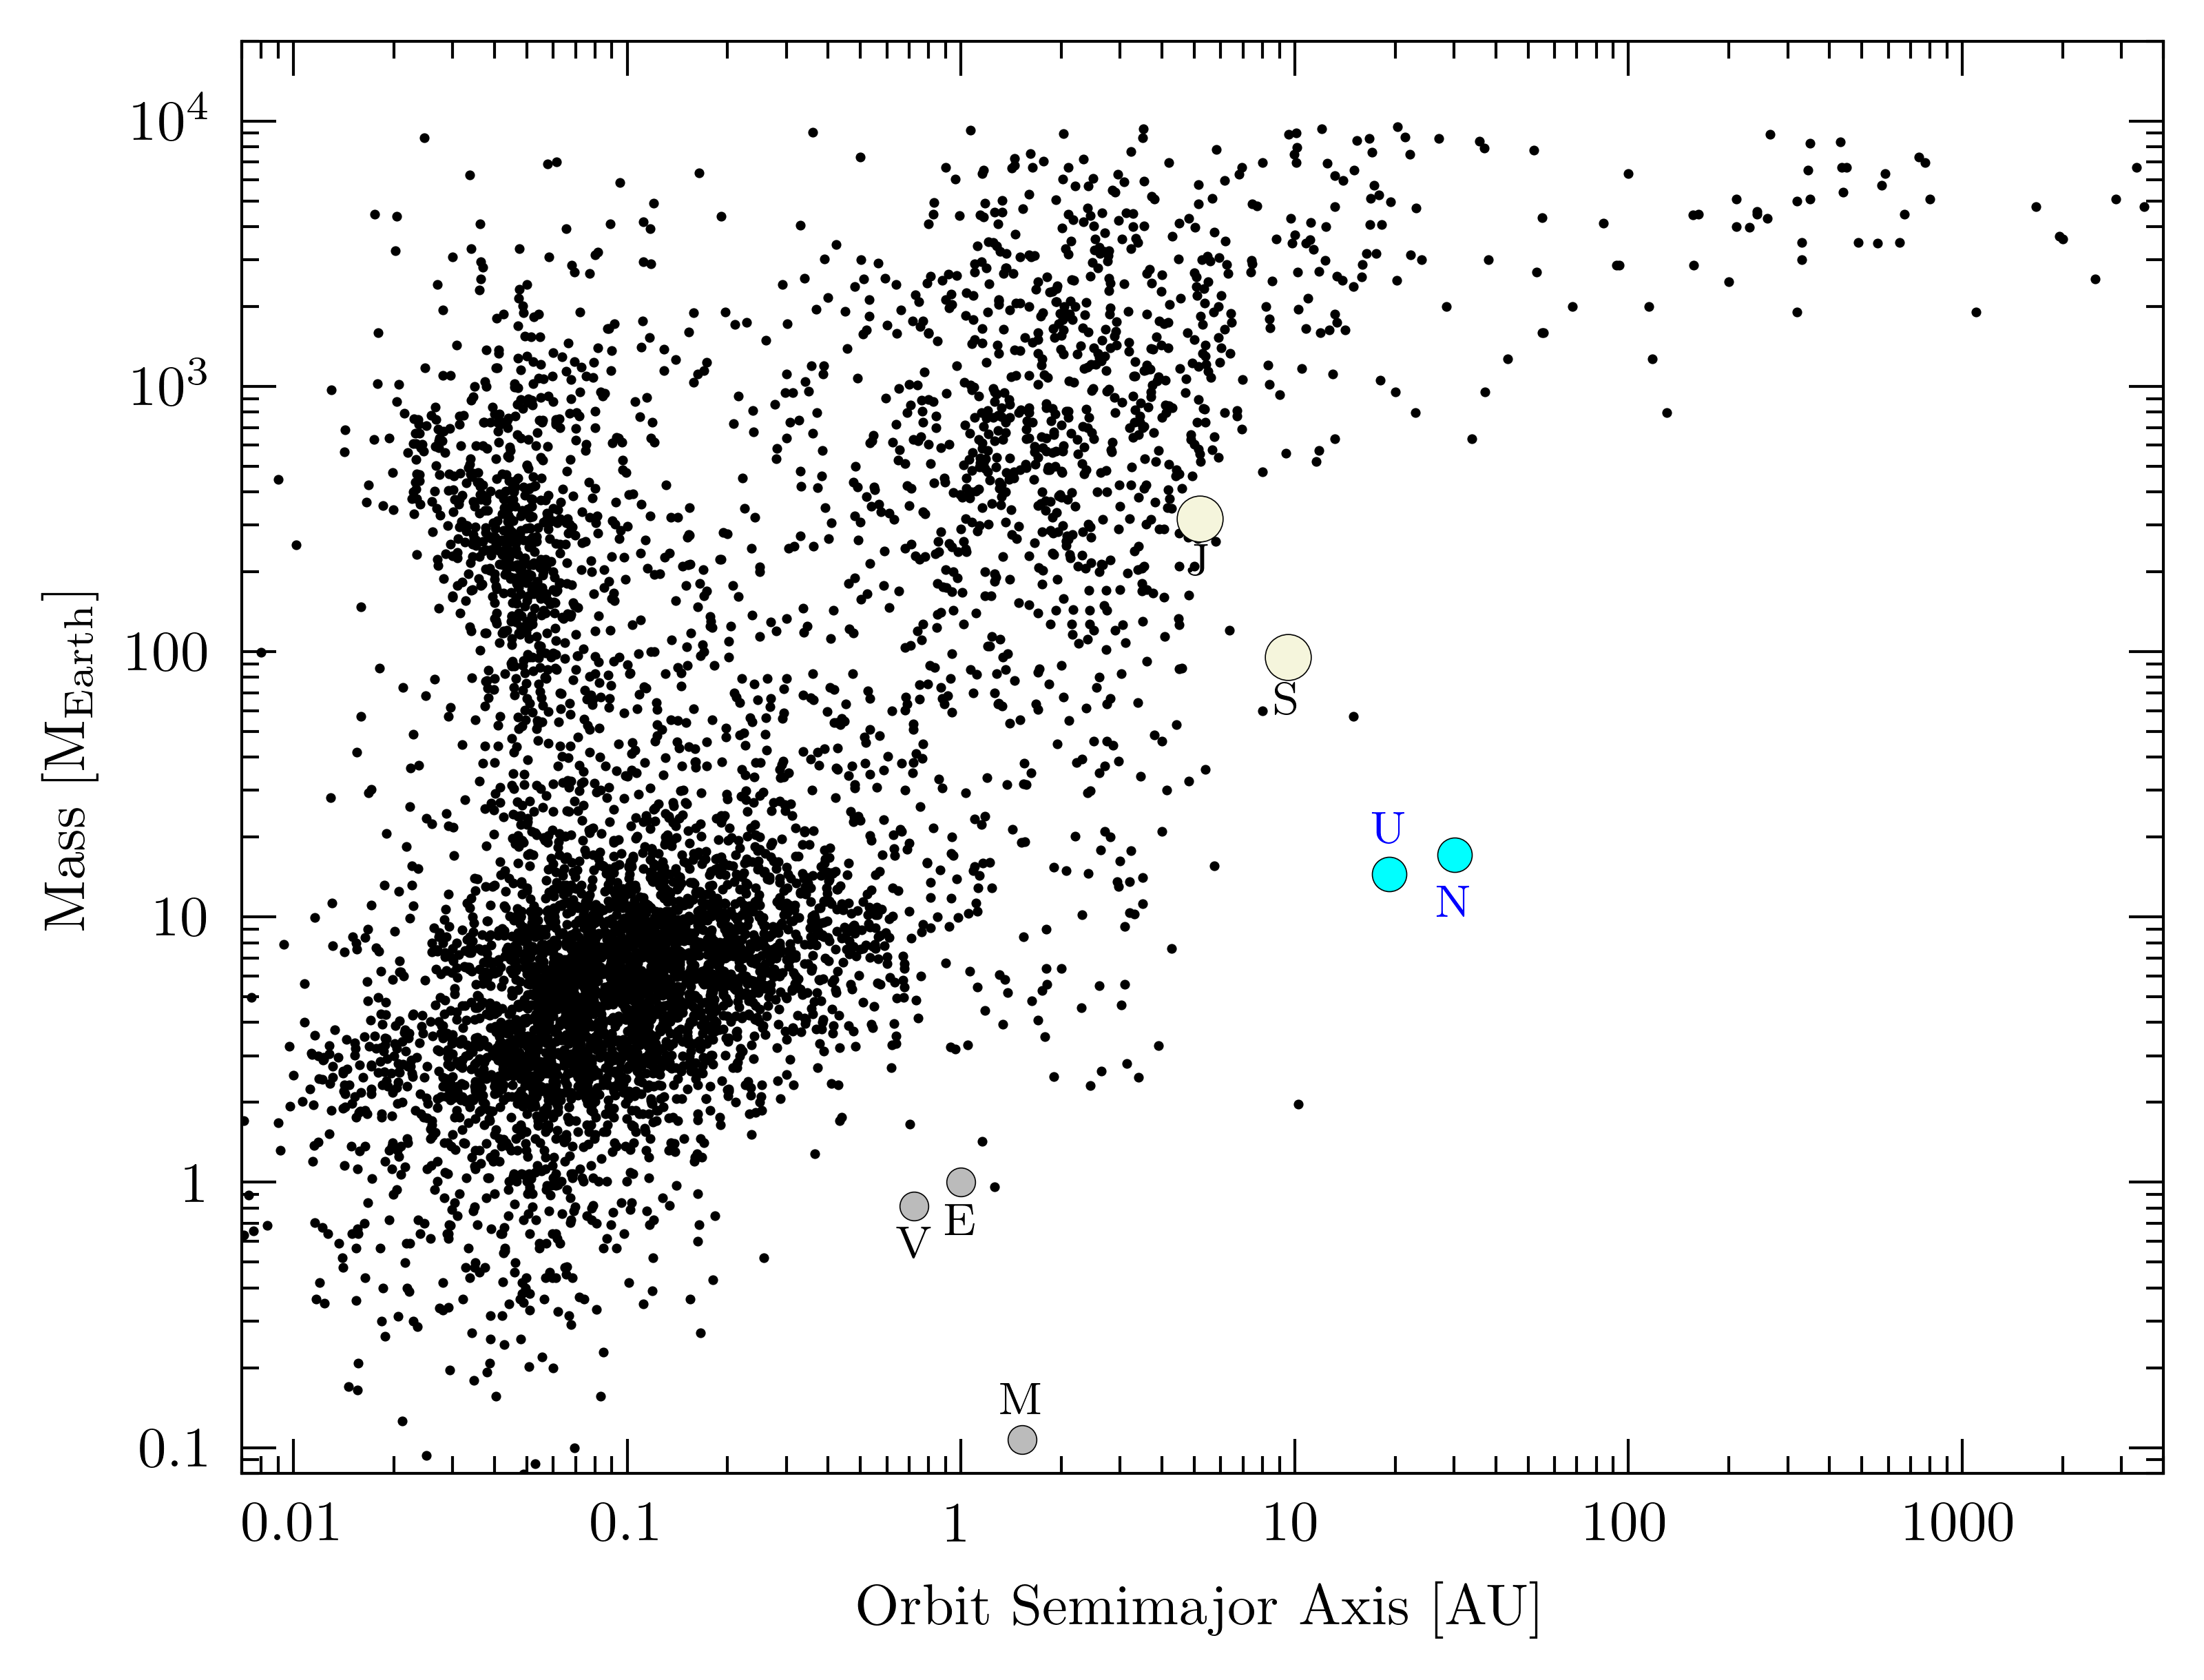

In [15]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(aMin,aMax)
ax.set_xscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10.0,subs=(1.0,),numticks=100))
ax.xaxis.set_minor_locator(LogLocator(base=10.0,subs=np.arange(2,10)*0.1,numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks([0.01,0.1,1,10,100,1000])
ax.set_xticklabels(['0.01','0.1','1','10','100','1000'])
ax.set_xlabel(r'Orbit Semimajor Axis [AU]',fontsize=axisFontSize)

ax.set_ylim(mMin,mMax)
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10.0,subs=(1.0,),numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0,subs=np.arange(2,10)*0.1,numticks=100))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_yticks([0.1,1,10,100,1e3,1e4])
ax.set_yticklabels(['0.1','1','10','100','10$^3$','10$^4$'])
ax.set_ylabel(r'Mass [M$_{\rm Earth}$]',fontsize=axisFontSize)

# exoplanets

ax.plot(exSMA,exMass,'o',mfc='black',mec='black',ms=1.5,mew=0.2,zorder=5)
    
# Major bodies (planets, dwarf planets, giant moons)

for i in range(len(bodyName)):
    t = bodyType[i]
    ax.plot(bodyAU[i],bodyMass[i],'o',mfc=bodyColor[t],mec='black',ms=bodySize[t],mew=0.2,zorder=10)

    if t == 'G':
        labelTxt = bodyName[i]
        ax.text(bodyAU[i],bodyMass[i]/1.25,labelTxt[0],va='top',ha='center',fontsize=labelFontSize,
                color='black',zorder=10)    
    elif t == 'I':
        labelTxt = bodyName[i]
        if bodyName[i] == 'Uranus':
            ax.text(bodyAU[i],1.2*bodyMass[i],labelTxt[0],va='bottom',ha='center',fontsize=labelFontSize,
                    color='blue',zorder=10)    
        else:
            ax.text(bodyAU[i],bodyMass[i]/1.3,labelTxt[0],va='top',ha='center',fontsize=labelFontSize,
                    color='blue',zorder=10)    
            
    elif t == 'T':
        labelTxt = bodyName[i][0]
        if bodyName[i]=='Mars':
            ax.text(bodyAU[i],1.15*bodyMass[i],'M',va='bottom',ha='center',fontsize=labelFontSize,
                color='black',zorder=10)
        elif bodyName[i]=='Venus' or bodyName[i] == 'Earth':
            ax.text(bodyAU[i],bodyMass[i]/1.2,labelTxt,va='top',ha='center',fontsize=labelFontSize,
                color='black',zorder=10)          
#        else:
#            ax.text(bodyAU[i],bodyMass[i]/1.2,labelTxt,va='top',ha='center',fontsize=labelFontSize,
#                color='black',zorder=10)

# make the plot and hardcopy

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()